In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count
import pennylane as qml
from matplotlib import pyplot as plt

In [23]:
n_qubits = 5
amplitudes = np.random.rand(32)
amplitudes /= np.linalg.norm(amplitudes)
# amplitudes = np.pad(amplitudes, (0, 32 - len(amplitudes)), mode='constant')
params = np.random.rand(9*n_qubits)
print(amplitudes)

[0.29643322 0.18237944 0.30697794 0.05881537 0.10611826 0.07595084
 0.28405551 0.09405947 0.14758228 0.13533929 0.06466228 0.1686075
 0.24681291 0.2068925  0.02893073 0.22942059 0.05209475 0.08468819
 0.26805427 0.30496676 0.30283342 0.13586707 0.10409904 0.09830437
 0.23048865 0.21430606 0.13862928 0.09386155 0.07564439 0.0732465
 0.02437974 0.02309647]


In [3]:
print(qml.io.plugin_converters.keys())

dict_keys(['qasm', 'qasm_file', 'qiskit', 'qiskit_noise', 'qiskit_op'])


In [4]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

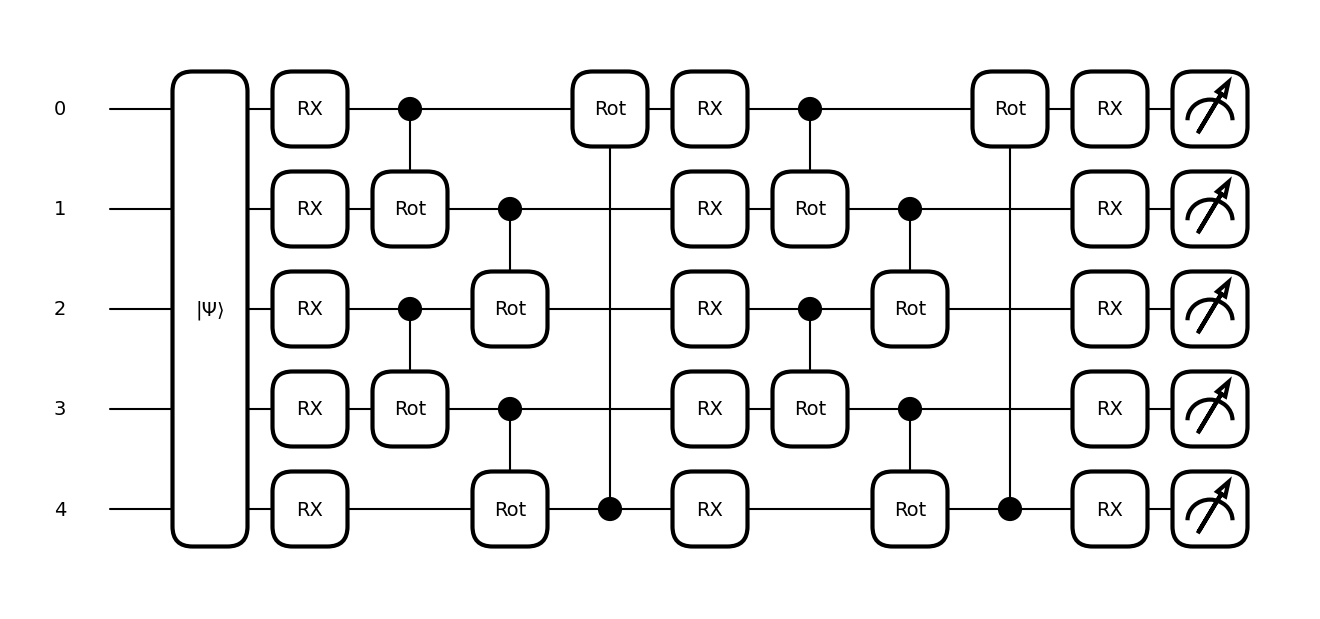

In [5]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_circuit(amplitude_array, params):
    q_circuit = QSVDDCircuit(n_qubits)
    q_circuit.qc_complete_design(amplitude_array, params, method="baa_lowrank")
    return qml.state()

qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(check_circuit)(amplitudes, params)

plt.show()

In [25]:
# Configuração do dispositivo para o benchmark
dev_bench = qml.device('default.qubit', wires=5)

def get_specs_for_method(method_name, amplitudes):
    """Gera um QNode temporário para extrair as métricas de um método específico."""
    @qml.qnode(dev_bench)
    def temp_circuit():
        q_circuit = QSVDDCircuit(n_qubits=5)
        mapping_fn = q_circuit.feature_mapping(amplitudes, method=method_name)
        mapping_fn(wires=range(5))
        return qml.state()

    # Extrai recursos usando a nova estrutura do PennyLane
    info = qml.specs(temp_circuit)()
    return info["resources"]

# --- Execução do Benchmark ---

methods_map = {
    "BAA LowRank":          "baa_lowrank",
    "Bidirectional":        "bdsp",
    "Divide and Conquer":   "dcsp",
    "Isometry":             "isometry",
    "Qiskit Native":        "qiskit",
    "UCGE":                 "ucge"
}

header = f" QUANTUM FEATURE MAPPING BENCHMARKS "
print(f"\n{header:=^75}")
print(f"{'Method Strategy':<25} | {'CNOTs':>8} | {'Depth':>8} | {'Total Gates':>12}")
print("-" * 75)

all_results = {}

for name, method_key in methods_map.items():
    try:
        res = get_specs_for_method(method_key, amplitudes)
        all_results[name] = res

        # Busca CNOT ou CX no dicionário de tipos de portas
        cnot_count = res.gate_types.get("CNOT", 0) + res.gate_types.get("CX", 0)

        print(f"{name:<25} | {cnot_count:>8} | {res.depth:>8} | {res.num_gates:>12}")
    except Exception as e:
        print(f"{name:<25} | Erro ao processar método: {str(e)[:30]}...")

print("-" * 75)



=================== QUANTUM FEATURE MAPPING BENCHMARKS ====================
Method Strategy           |    CNOTs |    Depth |  Total Gates
---------------------------------------------------------------------------
BAA LowRank               |       21 |       35 |           61
Bidirectional             | Erro ao processar método: The specified number of wires ...
Divide and Conquer        | Erro ao processar método: The specified number of wires ...
Isometry                  |       26 |       53 |           57
Qiskit Native             |       26 |       53 |           57
UCGE                      |       26 |       53 |           57
---------------------------------------------------------------------------


In [26]:
# --- Detalhamento de Portas ---
print(f"\n{' DETALHAMENTO DE PORTAS POR MÉTODO ':-^75}")

for name, res in all_results.items():
    gates_str = ", ".join([f"{gate}({count})" for gate, count in res.gate_types.items()])
    print(f"● {name:<23} → {gates_str}")

print("=" * 75)


-------------------- DETALHAMENTO DE PORTAS POR MÉTODO --------------------
● BAA LowRank             → U3(40), CNOT(21)
● Isometry                → U3(31), CNOT(26)
● Qiskit Native           → U3(31), CNOT(26)
● UCGE                    → U3(31), CNOT(26)


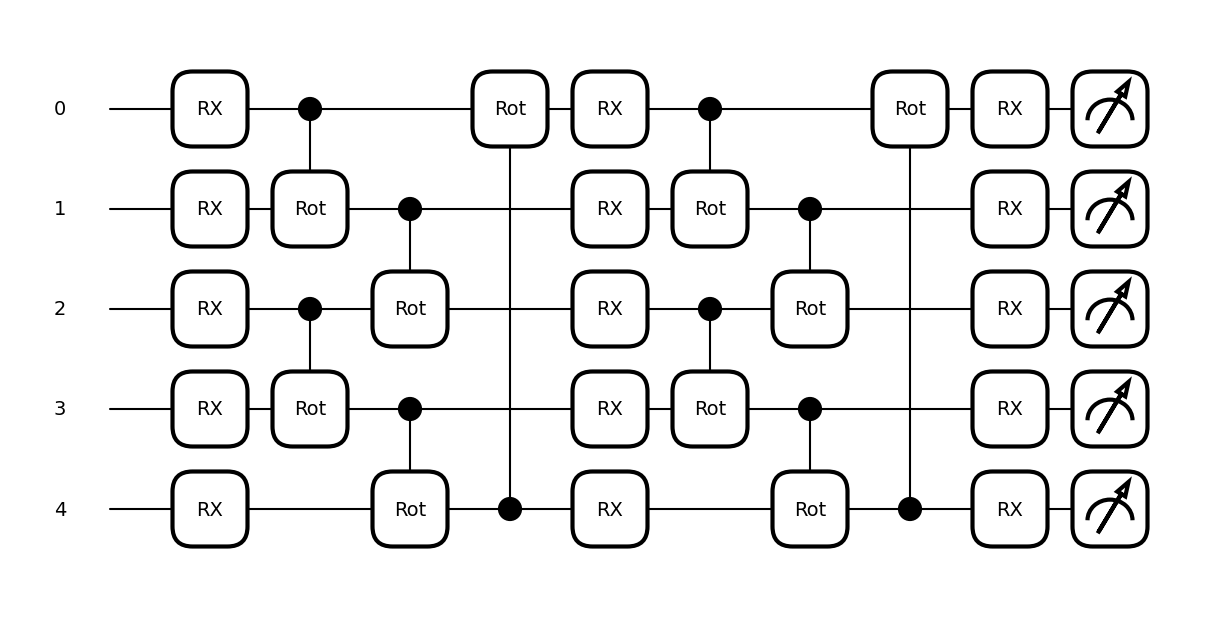

In [6]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_ansatz_circuit(params):
    q_circuit = QSVDDCircuit(n_qubits)
    q_circuit.ansatz(params)
    return qml.state()


qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(check_ansatz_circuit)(params)

plt.show()

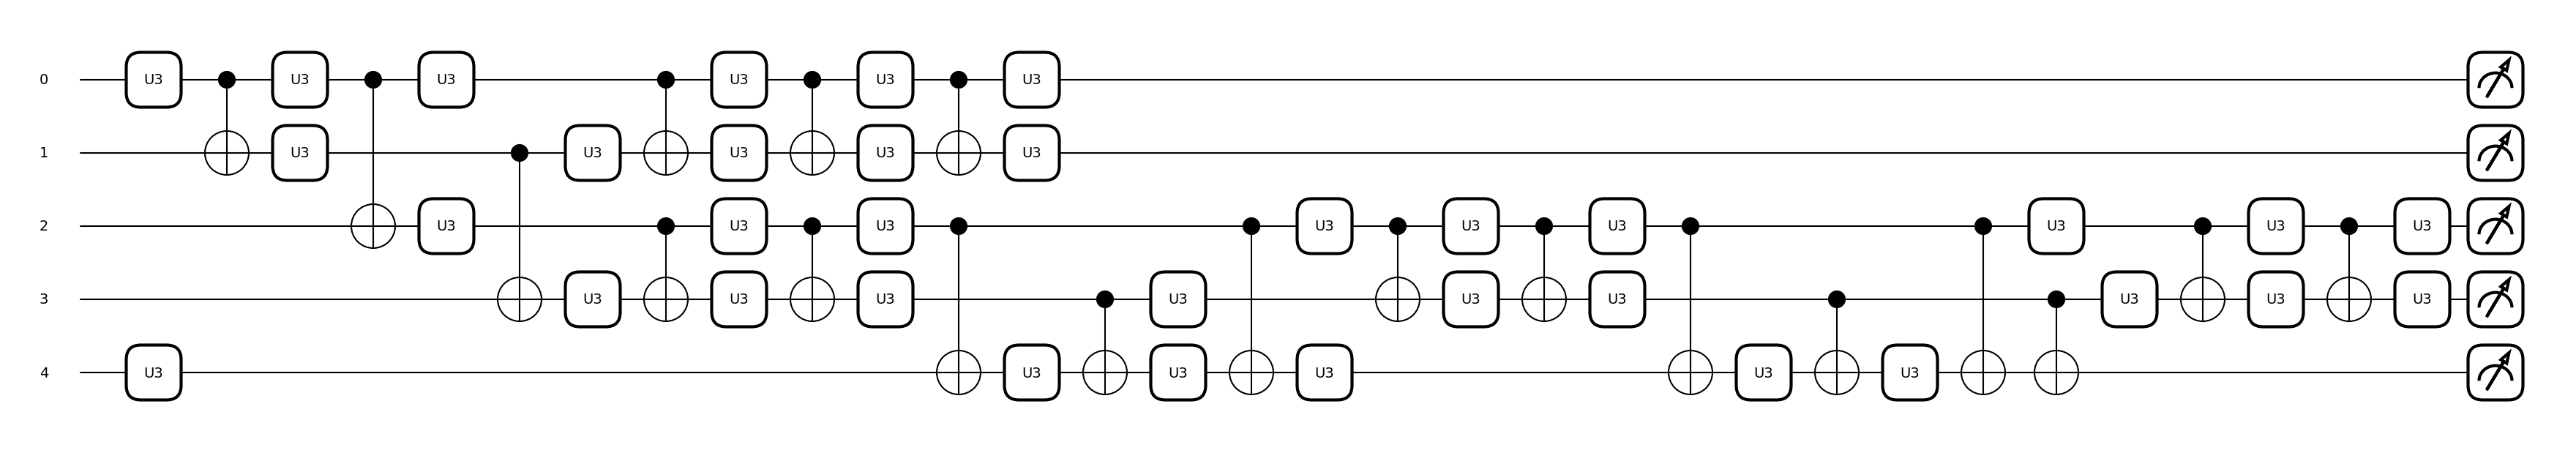

In [10]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_feature_mapping_circuit(amplitude_array):
    q_circuit = QSVDDCircuit(n_qubits)
    mapping_fn = q_circuit.feature_mapping(amplitude_array, method="baa_lowrank")
    mapping_fn(wires=range(n_qubits))
    return qml.state()

qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(check_feature_mapping_circuit)(amplitudes)

plt.show()